# 🐾 Fase 1 · Austin Animal Center
## Limpieza + EDA Univariante + Bivariante + Multivariante

**Pregunta central:** En el momento en que un animal llega al refugio, ¿cuál es el destino más probable?

---
### Índice
**PREPARACIÓN**
1. Carga y mapeo de las 4 clases

2. Selección de features disponibles al ingreso

3. Limpieza de edades inválidas y outliers

4. Tratamiento de nulos

5. Feature engineering final

6. Resumen del dataset limpio

**EDA UNIVARIANTE**
7. Variable objetivo

8. Variables categóricas (distribución individual)

9. Variables numéricas (distribución individual)

**EDA BIVARIANTE**
10. Tipo de animal vs outcome

11. Condición de ingreso vs outcome

12. Tipo de ingreso vs outcome

13. Edad vs outcome

14. Sexo y estado reproductivo vs outcome

15. Raza vs outcome

16. Color vs outcome

17. Estación vs outcome

18. Cramér's V — ranking de features

**EDA MULTIVARIANTE**
19. Animal type × intake_condition → outcome

20. Animal type × age_group → outcome

21. intake_type × intake_condition → outcome

22. Repro_status × animal_type → outcome

23. Matriz de correlaciones numéricas

24. Pairplot de numéricas coloreado por clase

25. PCA — separabilidad de clases

**CIERRE**
26. Conclusiones

27. Exportar `animal_classification.csv`

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

CLASS_ORDER  = ['Adoption', 'Transfer', 'Return To Owner', 'At Risk']
CLASS_COLORS = {
    'Adoption':        '#2196F3',
    'Transfer':        '#4CAF50',
    'Return To Owner': '#FF9800',
    'At Risk':         '#F44336',
}
PALETTE      = [CLASS_COLORS[c] for c in CLASS_ORDER]
SEASON_ORDER  = ['Spring', 'Summer', 'Fall', 'Winter']
SEASON_COLORS = {'Spring':'#74c69d','Summer':'#f4a261','Fall':'#e76f51','Winter':'#457b9d'}
TARGET = 'outcome_class'

print('✅ Librerías listas')

✅ Librerías listas


---
# PREPARACIÓN
## 1. Carga y mapeo de las 4 clases

In [92]:
FILE_PATH = '../data/processed/austin_animal_preprocessed.csv'
raw = pd.read_csv(FILE_PATH, low_memory=False)
print(f'Cargado: {raw.shape[0]:,} filas × {raw.shape[1]} columnas')

OUTCOME_MAP = {
    'Adoption':        'Adoption',
    'Rto-Adopt':       'Adoption',
    'Transfer':        'Transfer',
    'Return To Owner': 'Return To Owner',
    'Euthanasia':      'At Risk',
    'Died':            'At Risk',
    'Disposal':        'At Risk',
    'Missing':         None,
    'Unknown':         None,
    'Relocate':        None,
}

raw[TARGET] = raw['outcome_type'].map(OUTCOME_MAP)
before = len(raw)
raw = raw.dropna(subset=[TARGET])
print(f'Filas eliminadas (clases ambiguas): {before - len(raw):,}')
print(f'Dataset tras mapeo: {raw.shape[0]:,} filas')
print(raw[TARGET].value_counts())

Cargado: 160,358 filas × 38 columnas
Filas eliminadas (clases ambiguas): 142
Dataset tras mapeo: 160,216 filas
outcome_class
Adoption           73712
Transfer           40040
Return To Owner    36005
At Risk            10459
Name: count, dtype: int64


Filtrado del Animal Type para ajustar la complejidad y centralizar el modelo

In [93]:
# ── Filtrar solo perros y gatos ───────────────────────────────────────────────
ANIMALS_TO_KEEP = ['Dog', 'Cat']

before_filter = len(df)
df = df[df['animal_type_intake'].isin(ANIMALS_TO_KEEP)]
after_filter = len(df)

print(f'Filas antes del filtro : {before_filter:,}')
print(f'Filas después del filtro: {after_filter:,}')
print(f'Filas eliminadas       : {before_filter - after_filter:,}')
print(f'\nDistribución:')
print(df['animal_type_intake'].value_counts())

Filas antes del filtro : 160,216
Filas después del filtro: 152,990
Filas eliminadas       : 7,226

Distribución:
animal_type_intake
Dog    102014
Cat     50976
Name: count, dtype: int64


---
## 2. Selección de features disponibles al ingreso

In [94]:
FEATURES_INTAKE = [
    'animal_type_intake', 'breed_intake', 'color_intake',
    'sex_upon_intake', 'intake_type', 'intake_condition',
    'age_days', 'is_mix', 'sex', 'repro_status',
    'season', 'is_weekend', 'outcome_month',
]

available = [c for c in FEATURES_INTAKE if c in raw.columns]
missing   = [c for c in FEATURES_INTAKE if c not in raw.columns]
print(f'✅ Features disponibles ({len(available)}): {available}')
if missing:
    print(f'⚠️  No encontradas: {missing}')

df = raw[available + [TARGET]].copy()
print(f'\nDataset de trabajo: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✅ Features disponibles (13): ['animal_type_intake', 'breed_intake', 'color_intake', 'sex_upon_intake', 'intake_type', 'intake_condition', 'age_days', 'is_mix', 'sex', 'repro_status', 'season', 'is_weekend', 'outcome_month']

Dataset de trabajo: 160,216 filas × 14 columnas


---
## 3. Limpieza de edades inválidas y outliers

=== Diagnóstico age_days ===
count    160216.0
mean        822.9
std        1043.4
min       -1095.0
25%         120.0
50%         365.0
75%        1095.0
max        9125.0
Name: age_days, dtype: float64
Edades = 0  : 191
Edades < 0  : 31
Edades > 20a: 9


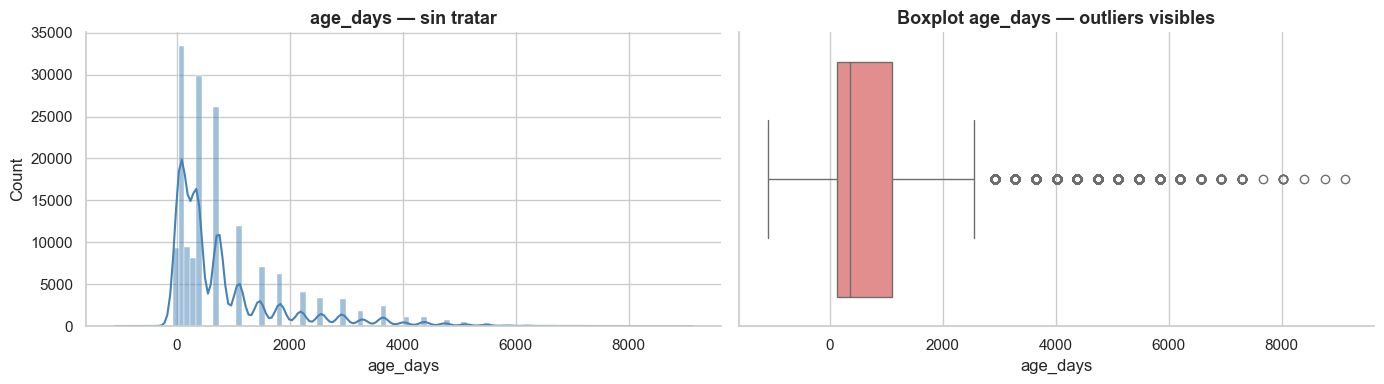

In [95]:
print('=== Diagnóstico age_days ===')
print(df['age_days'].describe().round(1))
print(f'Edades = 0  : {(df["age_days"] == 0).sum():,}')
print(f'Edades < 0  : {(df["age_days"] < 0).sum():,}')
print(f'Edades > 20a: {(df["age_days"] > 365*20).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['age_days'], bins=100, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('age_days — sin tratar')
sns.boxplot(x=df['age_days'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot age_days — outliers visibles')
plt.tight_layout()
plt.show()

Edades inválidas corregidas: 231
Nulos restantes en age_days: 0


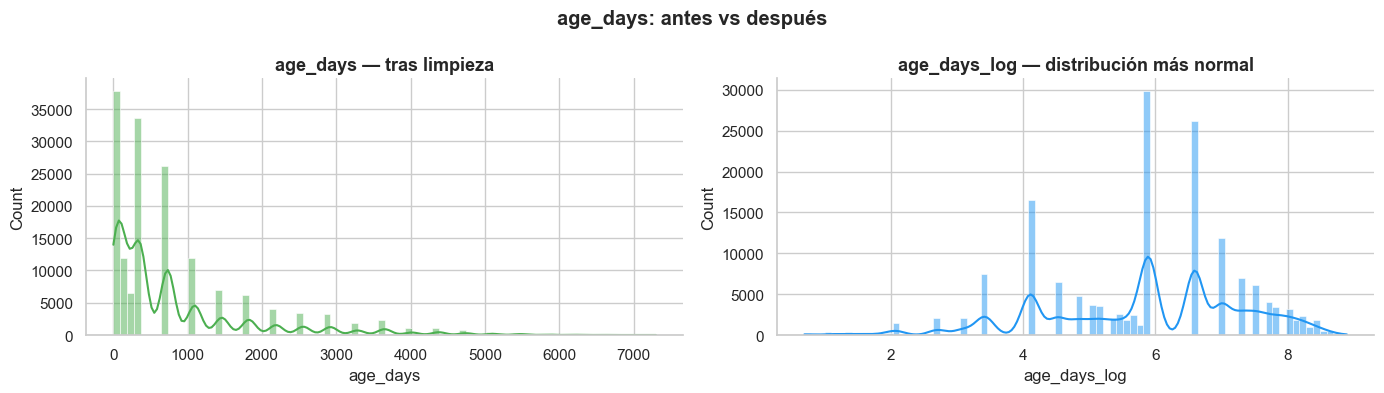

In [96]:
AGE_MIN = 1
AGE_MAX = 365 * 20

before_invalid = ((df['age_days'] < AGE_MIN) | (df['age_days'] > AGE_MAX)).sum()
df.loc[df['age_days'] < AGE_MIN, 'age_days'] = np.nan
df.loc[df['age_days'] > AGE_MAX, 'age_days'] = np.nan

if 'animal_type_intake' in df.columns:
    df['age_days'] = df.groupby('animal_type_intake')['age_days']\
                       .transform(lambda x: x.fillna(x.median()))
df['age_days'] = df['age_days'].fillna(df['age_days'].median())

df['age_days_log'] = np.log1p(df['age_days'])

print(f'Edades inválidas corregidas: {before_invalid:,}')
print(f'Nulos restantes en age_days: {df["age_days"].isnull().sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['age_days'], bins=80, ax=axes[0], color='#4CAF50', kde=True)
axes[0].set_title('age_days — tras limpieza')
sns.histplot(df['age_days_log'], bins=80, ax=axes[1], color='#2196F3', kde=True)
axes[1].set_title('age_days_log — distribución más normal')
plt.suptitle('age_days: antes vs después', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Tratamiento de nulos

In [97]:
null_df = pd.DataFrame({
    'nulos':      df.isnull().sum(),
    'porcentaje': (df.isnull().mean() * 100).round(2)
}).sort_values('porcentaje', ascending=False)
null_df = null_df[null_df['nulos'] > 0]

if not null_df.empty:
    display(null_df.style.bar(subset=['porcentaje'], color='#d65f5f'))
    for col in df.select_dtypes('object').columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna('Unknown')
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
else:
    print('✅ Sin nulos')

print(f'Nulos restantes: {df.isnull().sum().sum()}')

✅ Sin nulos
Nulos restantes: 0


---
## 5. Feature engineering 

In [98]:
# Color primario
df['primary_color'] = df['color_intake'].str.split('/').str[0].str.strip()

# Grupo de edad con Senior absorbiendo outliers
bins   = [0, 180, 365, 1095, 2555, np.inf]
labels = [
    'Cachorro (<6m)',
    'Joven (6m-1a)',
    'Adulto joven (1-3a)',
    'Adulto (3-7a)',
    'Senior (>7a)'
]
df['age_group'] = pd.cut(df['age_days'], bins=bins, labels=labels)

print('✅ age_group creada')
print(df['age_group'].value_counts().reindex(labels))

# is_mix si no existe
if 'is_mix' not in df.columns:
    df['is_mix'] = df['breed_intake'].str.lower().str.contains('mix', na=False).astype(int)

# Sex + repro combinada
df['sex_repro'] = df['sex'] + '_' + df['repro_status']

print(f'✅ Features creadas: primary_color, age_group, sex_repro')
print(f'Shape: {df.shape}')

✅ age_group creada
age_group
Cachorro (<6m)         49851
Joven (6m-1a)          40137
Adulto joven (1-3a)    38110
Adulto (3-7a)          20542
Senior (>7a)           11576
Name: count, dtype: int64
✅ Features creadas: primary_color, age_group, sex_repro
Shape: (160216, 18)


---
## 6. Resumen del dataset limpio

In [99]:
vc  = df[TARGET].value_counts().reindex(CLASS_ORDER)
pct = (vc / vc.sum() * 100).round(2)

print('=' * 60)
print('        RESUMEN DEL DATASET LIMPIO')
print('=' * 60)
print(f'  Filas      : {df.shape[0]:,}')
print(f'  Columnas   : {df.shape[1]}')
print(f'  Nulos      : {df.isnull().sum().sum()}')
print(f'  Duplicados : {df.duplicated().sum()}')
print()
for cls in CLASS_ORDER:
    bar = '█' * int(pct[cls])
    print(f'  {cls:<18} {vc[cls]:>7,}  ({pct[cls]:>5.1f}%)  {bar}')
print(f'\n  Ratio desbalance: {vc.max()/vc.min():.1f}x → class_weight="balanced" requerido')

        RESUMEN DEL DATASET LIMPIO
  Filas      : 160,216
  Columnas   : 18
  Nulos      : 0
  Duplicados : 38498

  Adoption            73,712  ( 46.0%)  ██████████████████████████████████████████████
  Transfer            40,040  ( 25.0%)  ████████████████████████
  Return To Owner     36,005  ( 22.5%)  ██████████████████████
  At Risk             10,459  (  6.5%)  ██████

  Ratio desbalance: 7.0x → class_weight="balanced" requerido


---
# EDA UNIVARIANTE
## 7. Variable objetivo

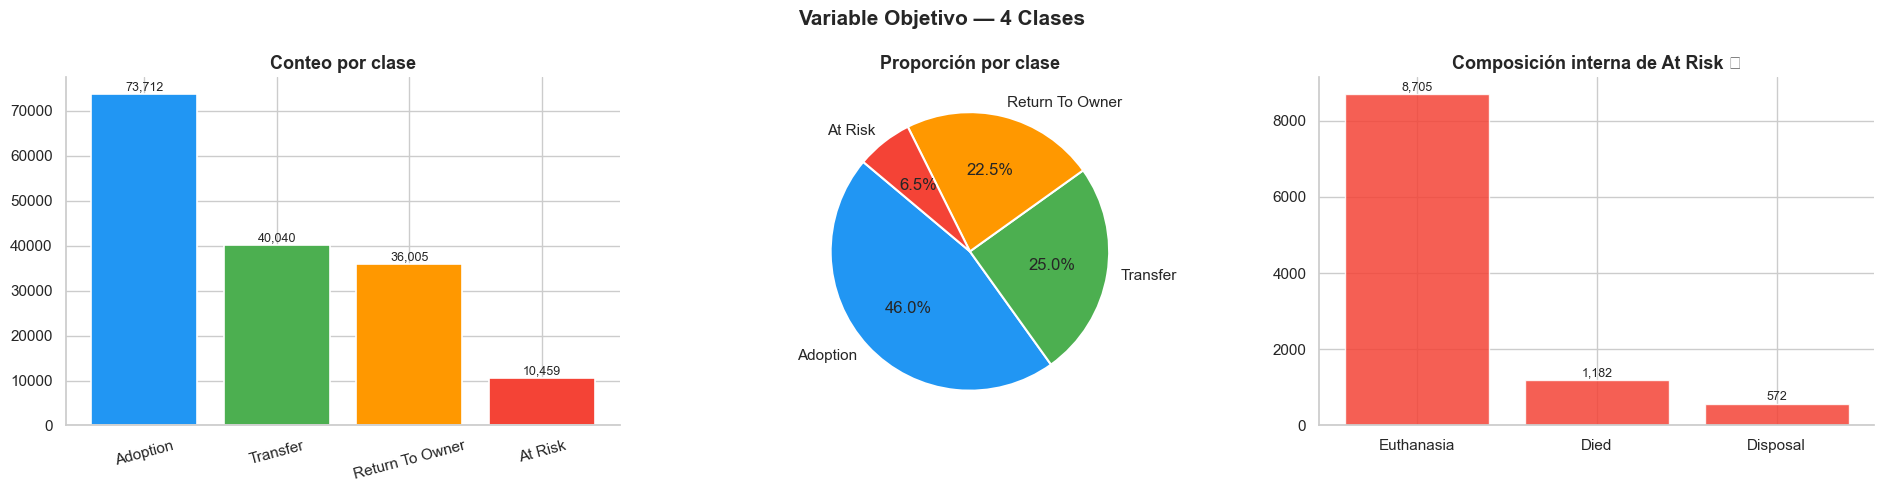

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

bars = axes[0].bar(CLASS_ORDER, vc.values, color=PALETTE, edgecolor='white', linewidth=1.2)
axes[0].set_title('Conteo por clase')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

axes[1].pie(vc, labels=CLASS_ORDER, autopct='%1.1f%%', colors=PALETTE,
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Proporción por clase')

ar_detail = raw[raw[TARGET]=='At Risk']['outcome_type'].value_counts()
axes[2].bar(ar_detail.index, ar_detail.values, color='#F44336', edgecolor='white', alpha=0.85)
axes[2].set_title('Composición interna de At Risk 🔴')
for bar in axes[2].patches:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Variable Objetivo — 4 Clases', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Variables categóricas — distribución individual

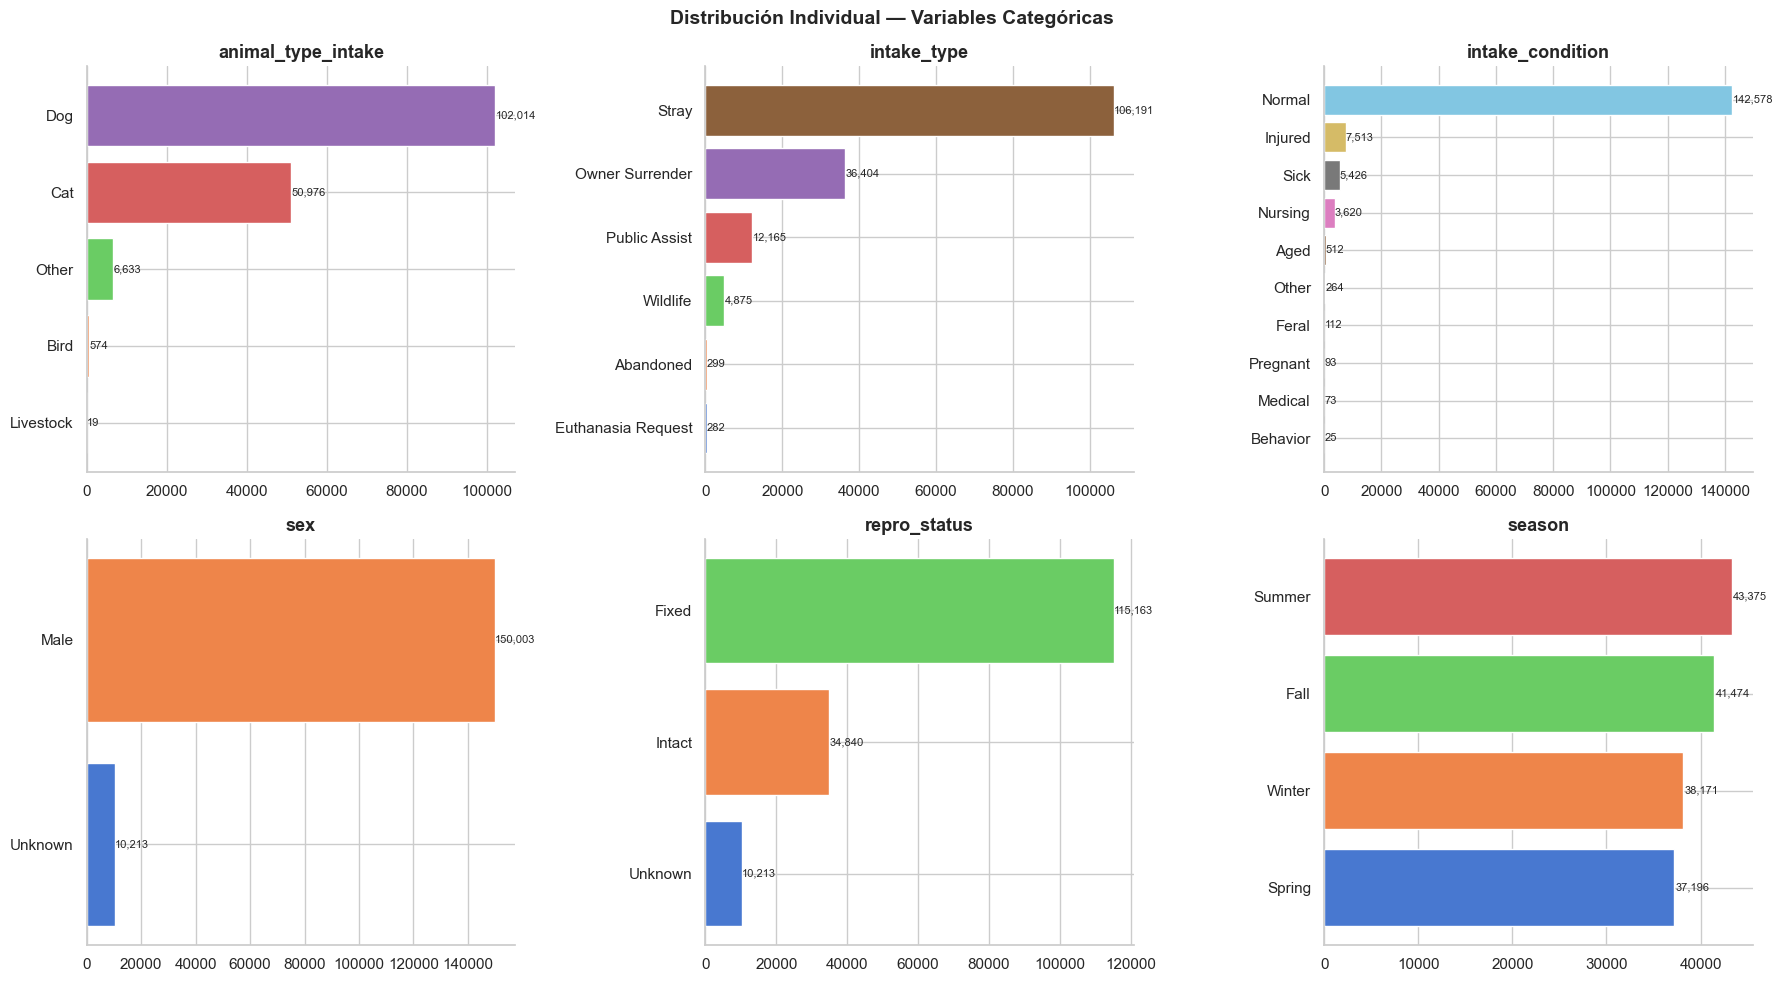

In [101]:
CAT_UNIVAR = ['animal_type_intake', 'intake_type', 'intake_condition',
              'sex', 'repro_status', 'season']
CAT_UNIVAR = [c for c in CAT_UNIVAR if c in df.columns]

n = len(CAT_UNIVAR)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_UNIVAR):
    vc_i = df[col].value_counts().head(12)
    axes[i].barh(vc_i.index[::-1], vc_i.values[::-1],
                 color=sns.color_palette('muted', len(vc_i)), edgecolor='white')
    axes[i].set_title(col)
    for j, v in enumerate(vc_i.values[::-1]):
        axes[i].text(v+100, j, f'{v:,.0f}', va='center', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución Individual — Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Variables numéricas — distribución individual

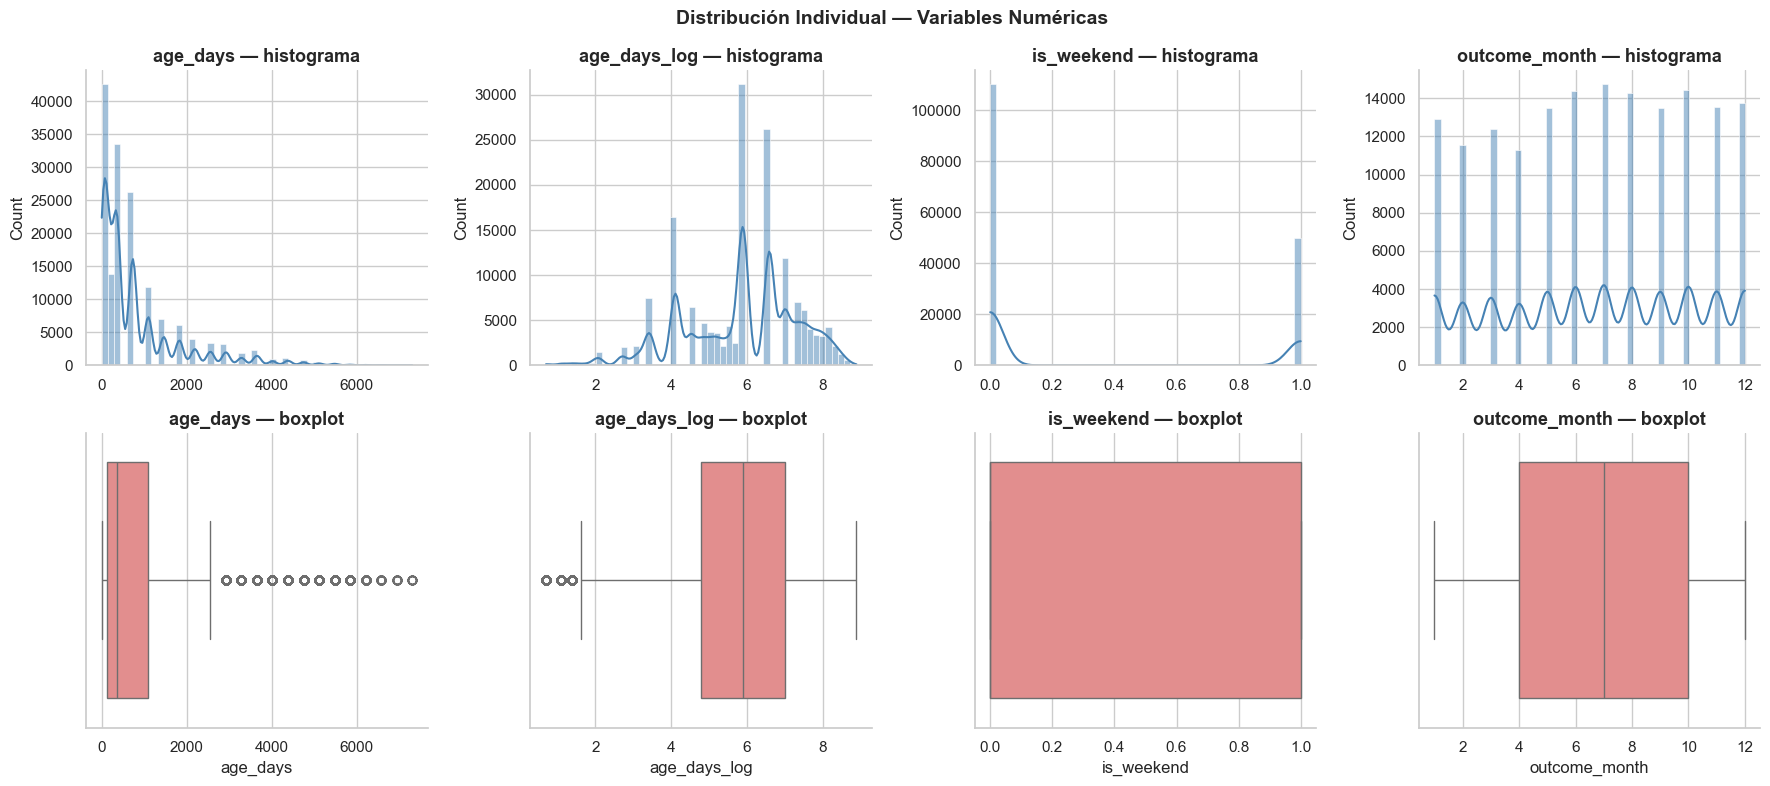

Estadísticas descriptivas:


,age_days,age_days_log,is_weekend,outcome_month
count,160216.000000,160216.000000,160216.000000,160216.000000
mean,823.140000,5.860000,0.310000,6.670000
std,1041.500000,1.500000,0.460000,3.410000
min,1.000000,0.690000,0.000000,1.000000
25%,120.000000,4.800000,0.000000,4.000000
50%,365.000000,5.900000,0.000000,7.000000
75%,1095.000000,7.000000,1.000000,10.000000
max,7300.000000,8.900000,1.000000,12.000000


In [102]:
NUM_UNIVAR = ['age_days', 'age_days_log', 'is_weekend', 'outcome_month']
NUM_UNIVAR = [c for c in NUM_UNIVAR if c in df.columns]

fig, axes = plt.subplots(2, len(NUM_UNIVAR), figsize=(18, 8))

for i, col in enumerate(NUM_UNIVAR):
    # Histograma
    sns.histplot(df[col], bins=50, kde=True, ax=axes[0][i], color='steelblue')
    axes[0][i].set_title(f'{col} — histograma')
    axes[0][i].set_xlabel('')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1][i], color='lightcoral')
    axes[1][i].set_title(f'{col} — boxplot')

plt.suptitle('Distribución Individual — Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas descriptivas:')
display(df[NUM_UNIVAR].describe().round(2)
          .style.background_gradient(cmap='Blues'))

---
# EDA BIVARIANTE
## 10. Tipo de animal vs outcome

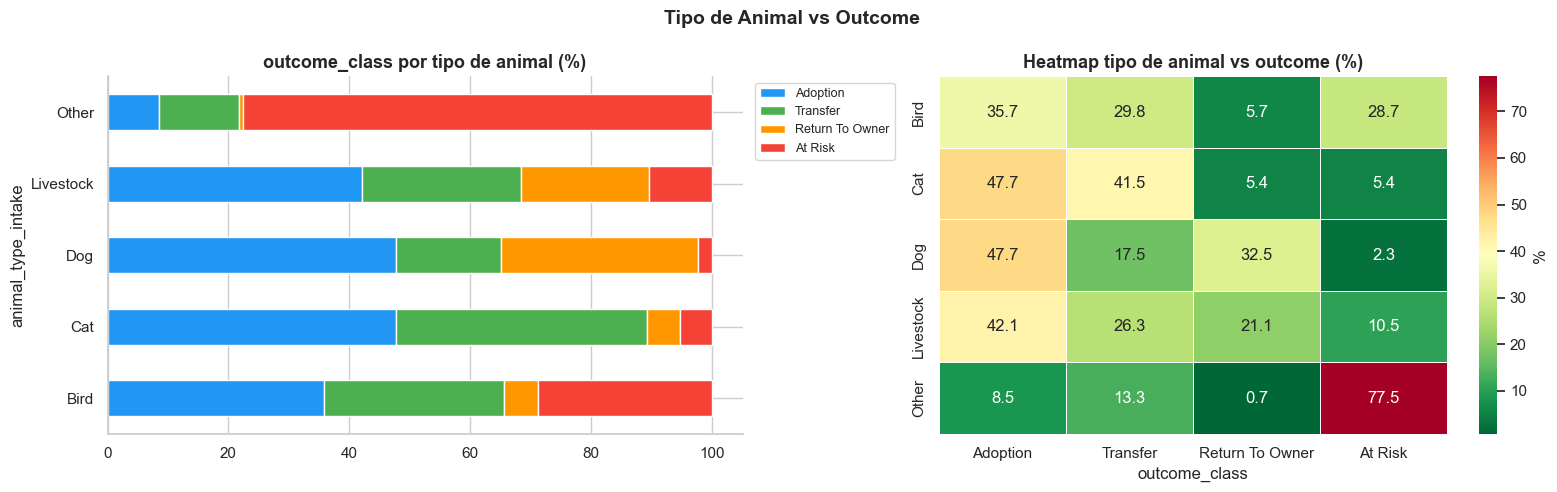

% At Risk por tipo:


outcome_class,At Risk
animal_type_intake,
Other,77.5%
Bird,28.7%
Livestock,10.5%
Cat,5.4%
Dog,2.3%


In [103]:
col = 'animal_type_intake'
ct  = pd.crosstab(df[col], df[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ct_pct.plot(kind='barh', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('outcome_class por tipo de animal (%)')
axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label':'%'})
axes[1].set_title('Heatmap tipo de animal vs outcome (%)')
axes[1].set_ylabel('')

plt.suptitle('Tipo de Animal vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('% At Risk por tipo:')
display(ct_pct[['At Risk']].sort_values('At Risk', ascending=False)
          .style.bar(color='#F44336').format('{:.1f}%'))

---
## 11. Condición de ingreso vs outcome

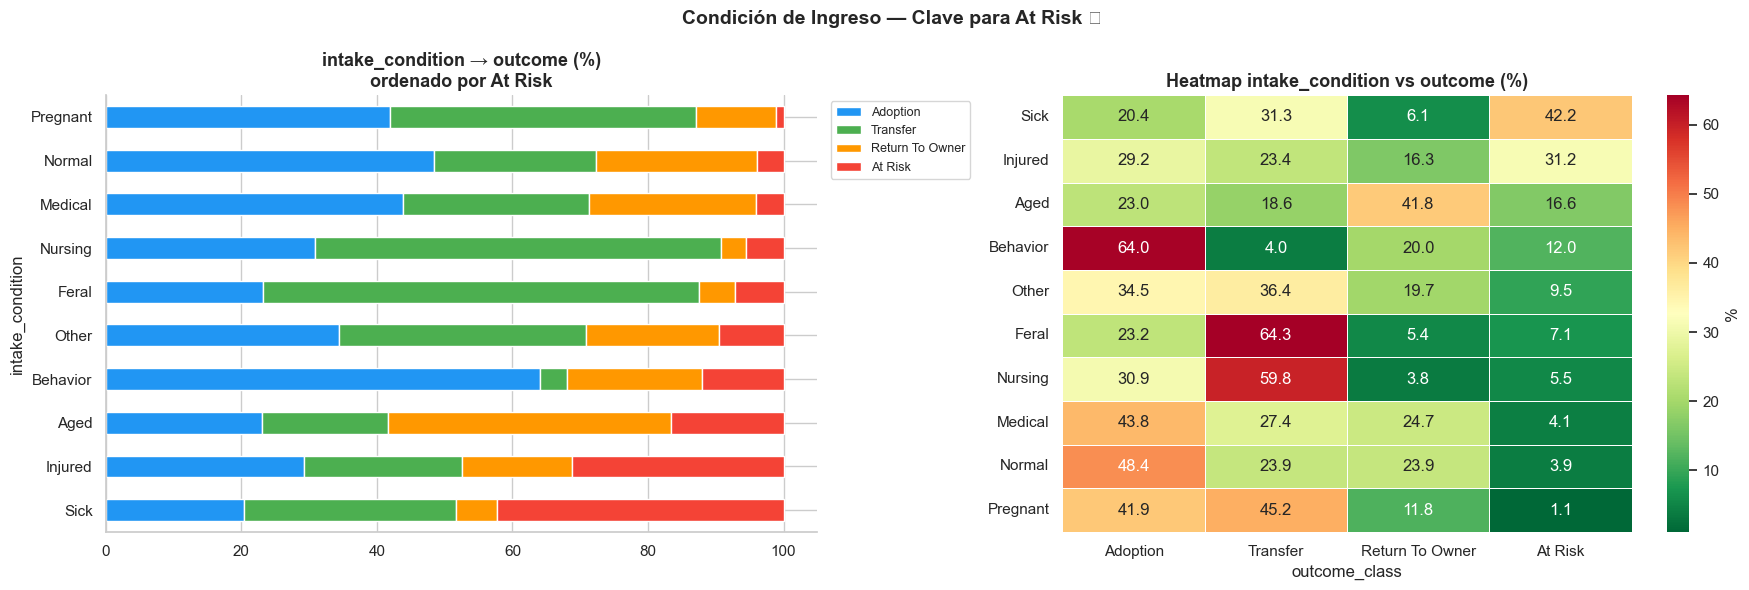

In [104]:
ct_ic  = pd.crosstab(df['intake_condition'], df[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
ct_ic_pct = ct_ic.div(ct_ic.sum(axis=1), axis=0) * 100
ct_ic_pct = ct_ic_pct.sort_values('At Risk', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ct_ic_pct.plot(kind='barh', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('intake_condition → outcome (%)\nordenado por At Risk')
axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

sns.heatmap(ct_ic_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label':'%'})
axes[1].set_title('Heatmap intake_condition vs outcome (%)')
axes[1].set_ylabel('')

plt.suptitle('Condición de Ingreso — Clave para At Risk 🔴', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Tipo de ingreso vs outcome

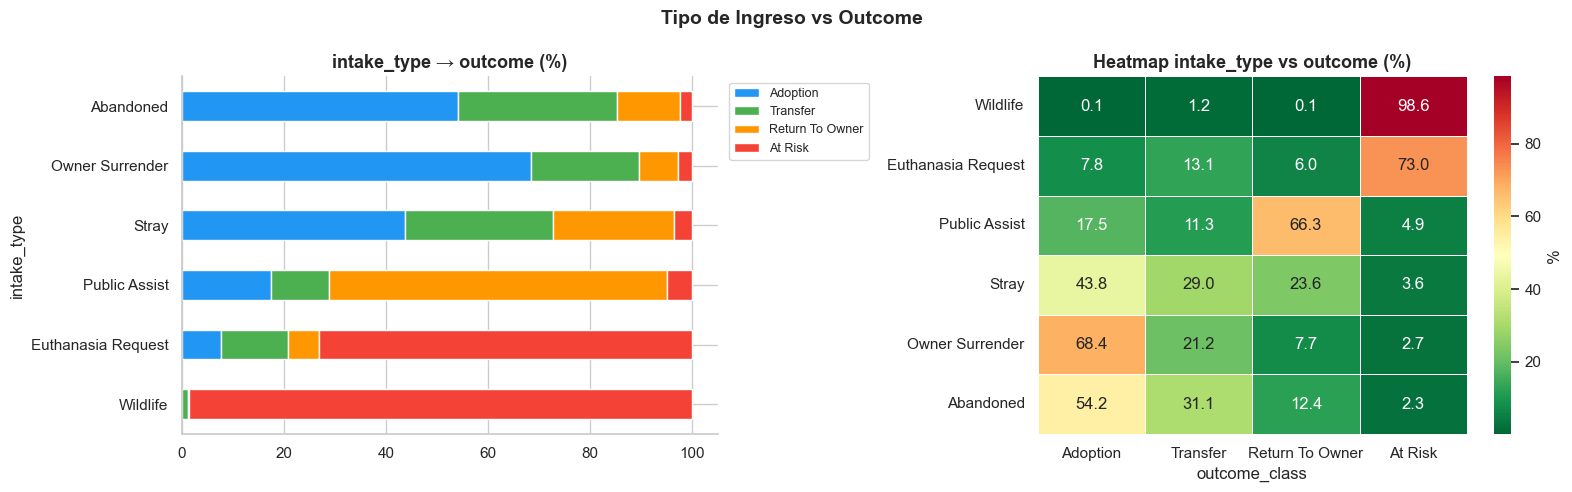

In [105]:
ct_it  = pd.crosstab(df['intake_type'], df[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
ct_it_pct = ct_it.div(ct_it.sum(axis=1), axis=0) * 100
ct_it_pct = ct_it_pct.sort_values('At Risk', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ct_it_pct.plot(kind='barh', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('intake_type → outcome (%)')
axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

sns.heatmap(ct_it_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label':'%'})
axes[1].set_title('Heatmap intake_type vs outcome (%)')
axes[1].set_ylabel('')

plt.suptitle('Tipo de Ingreso vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 13. Edad vs outcome

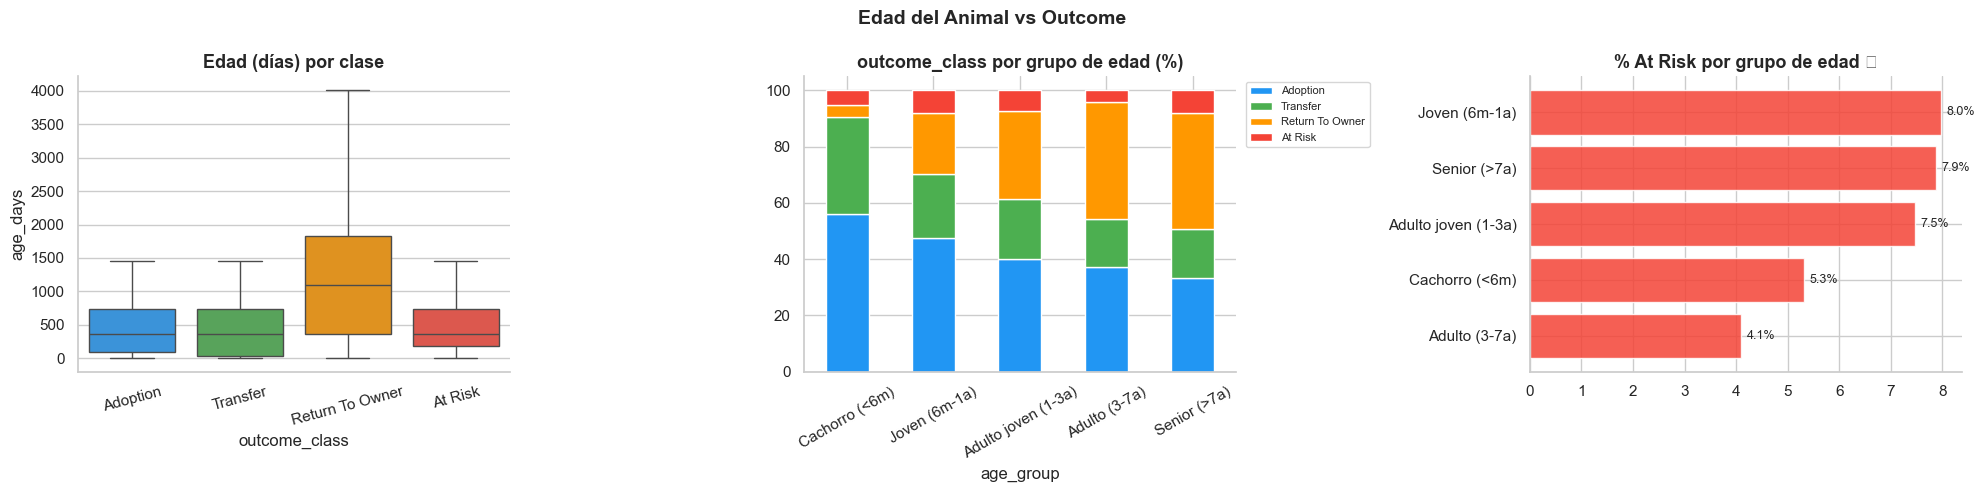

Estadísticas de edad por clase:


,median,mean,std
outcome_class,,,
Adoption,365.000000,675.000000,906.000000
Transfer,365.000000,623.000000,926.000000
Return To Owner,1095.000000,1340.000000,1207.000000
At Risk,365.000000,851.000000,1145.000000


In [106]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.boxplot(data=df, x=TARGET, y='age_days', order=CLASS_ORDER,
            palette=CLASS_COLORS, ax=axes[0], showfliers=False)
axes[0].set_title('Edad (días) por clase')
axes[0].tick_params(axis='x', rotation=15)

ct_ag = pd.crosstab(df['age_group'], df[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
ct_ag_pct = ct_ag.div(ct_ag.sum(axis=1), axis=0) * 100
ct_ag_pct.plot(kind='bar', stacked=True, ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('outcome_class por grupo de edad (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)

at_risk_age = ct_ag_pct['At Risk'].sort_values(ascending=True)
axes[2].barh(at_risk_age.index.astype(str), at_risk_age.values,
             color='#F44336', edgecolor='white', alpha=0.85)
axes[2].set_title('% At Risk por grupo de edad 🔴')
for i, v in enumerate(at_risk_age.values):
    axes[2].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Edad del Animal vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas de edad por clase:')
display(df.groupby(TARGET)['age_days'].agg(['median','mean','std'])
          .reindex(CLASS_ORDER).round(0)
          .style.background_gradient(cmap='Reds', subset=['median']))

---
## 14. Sexo y estado reproductivo vs outcome

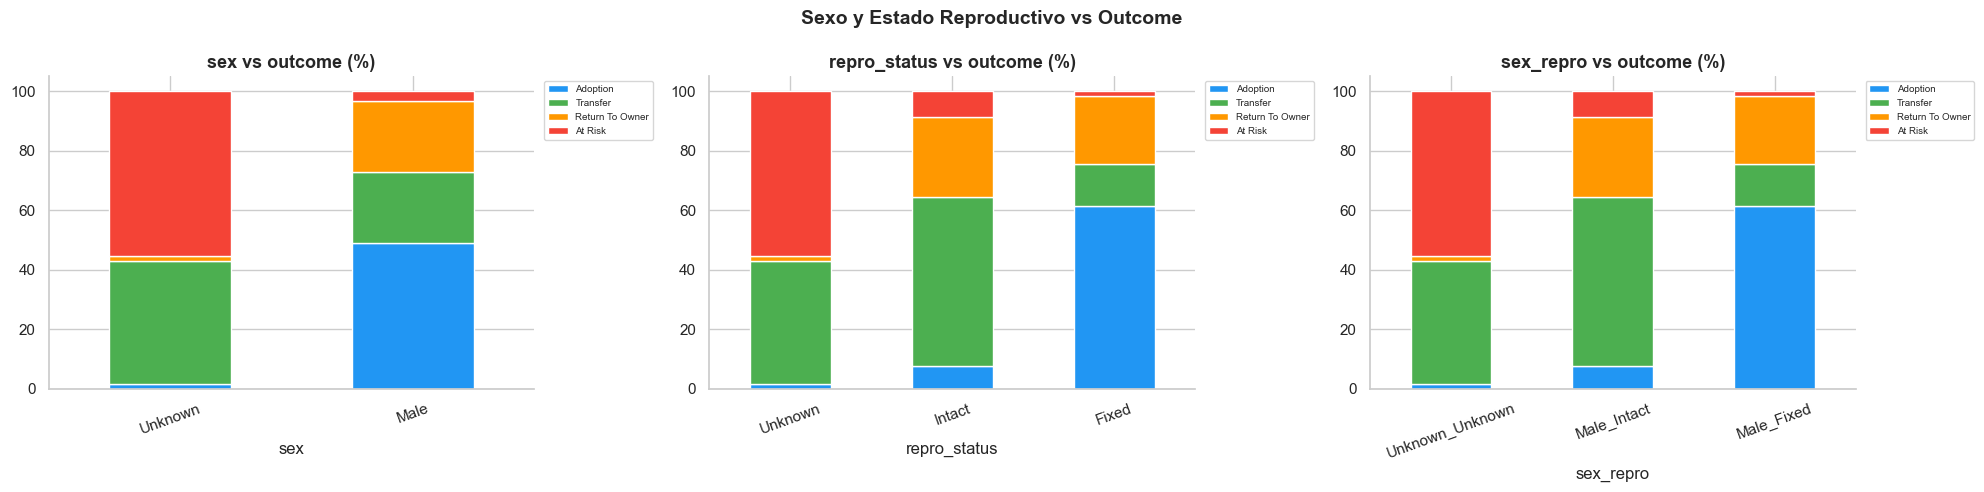

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(['sex', 'repro_status', 'sex_repro']):
    if col in df.columns:
        ct = pd.crosstab(df[col], df[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        ct_pct = ct_pct.sort_values('At Risk', ascending=False)
        ct_pct.plot(kind='bar', stacked=True, ax=axes[i], color=PALETTE, edgecolor='white')
        axes[i].set_title(f'{col} vs outcome (%)')
        axes[i].tick_params(axis='x', rotation=20)
        axes[i].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)

plt.suptitle('Sexo y Estado Reproductivo vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 15. Raza vs outcome

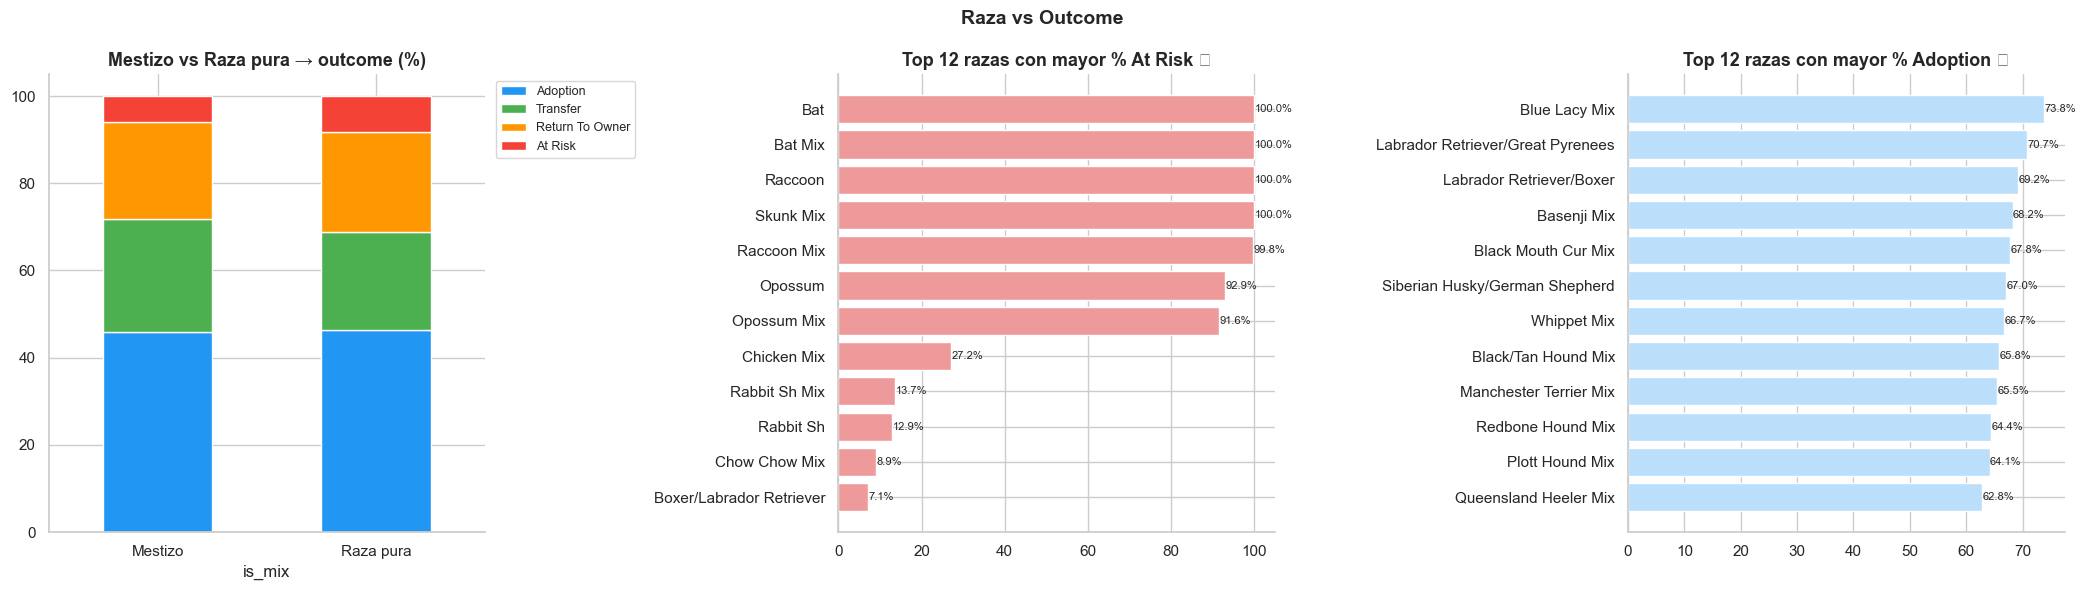

In [108]:
ct_mix = pd.crosstab(df['is_mix'].map({0:'Raza pura',1:'Mestizo'}), df[TARGET])
ct_mix = ct_mix.reindex(columns=CLASS_ORDER, fill_value=0)
ct_mix_pct = ct_mix.div(ct_mix.sum(axis=1), axis=0) * 100

breed_counts = df['breed_intake'].value_counts()
valid_breeds = breed_counts[breed_counts >= 100].index
df_b = df[df['breed_intake'].isin(valid_breeds)]
b_ct  = pd.crosstab(df_b['breed_intake'], df_b[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
b_pct = b_ct.div(b_ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ct_mix_pct.plot(kind='bar', stacked=True, ax=axes[0], color=PALETTE, edgecolor='white')
axes[0].set_title('Mestizo vs Raza pura → outcome (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

top_risk = b_pct['At Risk'].sort_values(ascending=False).head(12)
axes[1].barh(top_risk.index[::-1], top_risk.values[::-1], color='#EF9A9A', edgecolor='white')
axes[1].set_title('Top 12 razas con mayor % At Risk 🔴')
for i, v in enumerate(top_risk.values[::-1]):
    axes[1].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=8)

top_adopt = b_pct['Adoption'].sort_values(ascending=False).head(12)
axes[2].barh(top_adopt.index[::-1], top_adopt.values[::-1], color='#BBDEFB', edgecolor='white')
axes[2].set_title('Top 12 razas con mayor % Adoption 🔵')
for i, v in enumerate(top_adopt.values[::-1]):
    axes[2].text(v+0.1, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('Raza vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 16. Color vs outcome

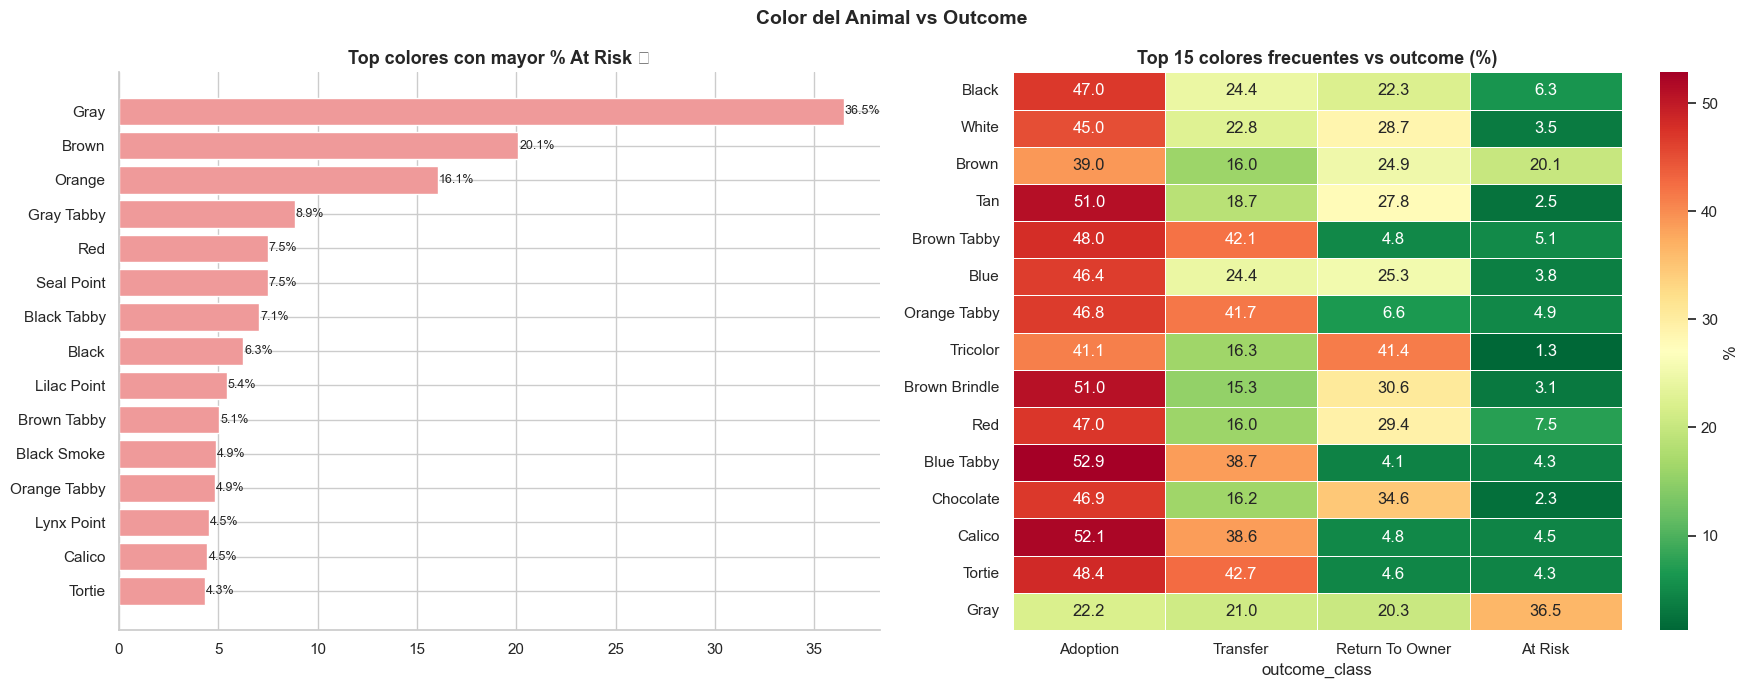

In [109]:
color_counts = df['primary_color'].value_counts()
valid_colors = color_counts[color_counts >= 100].index
df_c  = df[df['primary_color'].isin(valid_colors)]
c_ct  = pd.crosstab(df_c['primary_color'], df_c[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
c_pct = c_ct.div(c_ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_color_risk = c_pct['At Risk'].sort_values(ascending=True).tail(15)
axes[0].barh(top_color_risk.index, top_color_risk.values, color='#EF9A9A', edgecolor='white')
axes[0].set_title('Top colores con mayor % At Risk 🔴')
for i, v in enumerate(top_color_risk.values):
    axes[0].text(v+0.05, i, f'{v:.1f}%', va='center', fontsize=9)

top15 = c_pct.loc[color_counts[valid_colors].nlargest(15).index]
sns.heatmap(top15, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.4, cbar_kws={'label':'%'})
axes[1].set_title('Top 15 colores frecuentes vs outcome (%)')
axes[1].set_ylabel('')

plt.suptitle('Color del Animal vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 17. Estación del año vs outcome

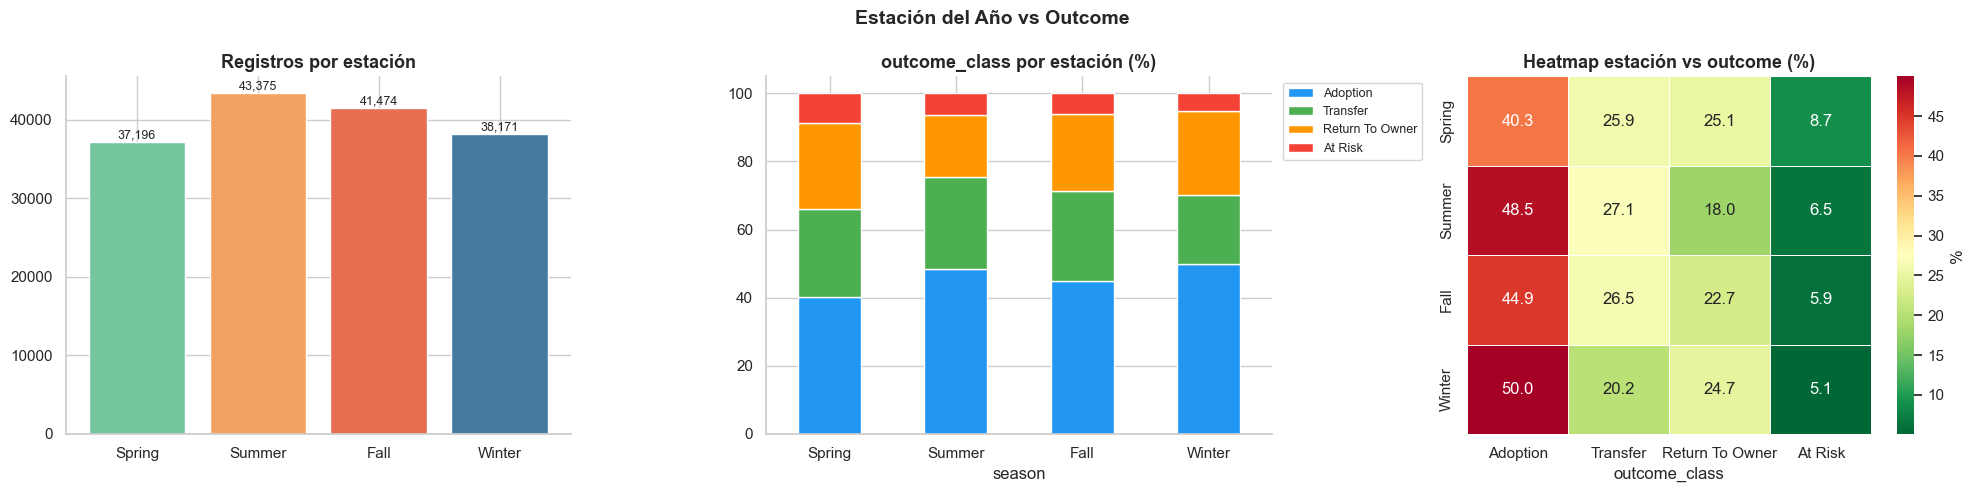

In [110]:
ct_s = pd.crosstab(df['season'], df[TARGET]).reindex(
    index=[s for s in SEASON_ORDER if s in df['season'].values],
    columns=CLASS_ORDER, fill_value=0)
ct_s_pct = ct_s.div(ct_s.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sc = df['season'].value_counts().reindex(SEASON_ORDER)
axes[0].bar(sc.index, sc.values,
            color=[SEASON_COLORS[s] for s in sc.index], edgecolor='white')
axes[0].set_title('Registros por estación')
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ct_s_pct.plot(kind='bar', stacked=True, ax=axes[1], color=PALETTE, edgecolor='white')
axes[1].set_title('outcome_class por estación (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)

sns.heatmap(ct_s_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[2], linewidths=0.5, cbar_kws={'label':'%'})
axes[2].set_title('Heatmap estación vs outcome (%)')
axes[2].set_ylabel('')

plt.suptitle('Estación del Año vs Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 18. Cramér's V — Ranking de features

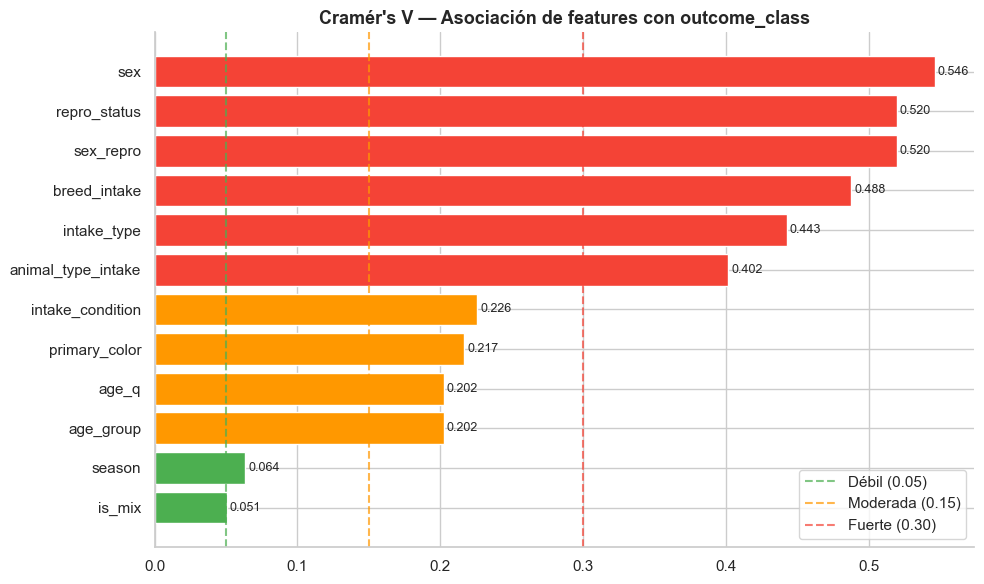

🏆 Ranking:


,Cramér's V
sex,0.5463
sex_repro,0.5197
repro_status,0.5197
breed_intake,0.4877
intake_type,0.4425
animal_type_intake,0.4017
intake_condition,0.2259
primary_color,0.2169
age_q,0.2025
age_group,0.2023


In [111]:
def cramers_v(col, target, data):
    try:
        ct = pd.crosstab(data[col].fillna('NaN').astype(str), data[target])
        chi2, _, _, _ = chi2_contingency(ct)
        n = ct.sum().sum()
        r, k = ct.shape
        phi2 = chi2 / n
        r2, k2 = r-1, k-1
        return np.sqrt(phi2 / min(k2, r2)) if min(k2, r2) > 0 else 0
    except:
        return np.nan

df_tmp = df.copy()
df_tmp['age_q'] = pd.qcut(df_tmp['age_days'], q=4, duplicates='drop', labels=False).astype(str)

EVAL_COLS = ['animal_type_intake','intake_type','intake_condition',
             'sex','repro_status','sex_repro','is_mix',
             'season','primary_color','breed_intake','age_group','age_q']
valid = [c for c in EVAL_COLS if c in df_tmp.columns]

assoc = {c: cramers_v(c, TARGET, df_tmp) for c in valid}
assoc_s = pd.Series(assoc).dropna().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(assoc_s)*0.5)))
bar_colors = ['#F44336' if v >= 0.3 else '#FF9800' if v >= 0.15
              else '#4CAF50' if v >= 0.05 else '#9E9E9E'
              for v in assoc_s.values]
ax.barh(assoc_s.index, assoc_s.values, color=bar_colors, edgecolor='white')
ax.axvline(0.05, color='#4CAF50', linestyle='--', alpha=0.7, label='Débil (0.05)')
ax.axvline(0.15, color='#FF9800', linestyle='--', alpha=0.7, label='Moderada (0.15)')
ax.axvline(0.30, color='#F44336', linestyle='--', alpha=0.7, label='Fuerte (0.30)')
ax.set_title("Cramér's V — Asociación de features con outcome_class", fontweight='bold')
ax.legend(loc='lower right')
for i, v in enumerate(assoc_s.values):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('🏆 Ranking:')
display(assoc_s.sort_values(ascending=False).to_frame("Cramér's V")
          .style.bar(color='#2196F3').format('{:.4f}'))

---
# EDA MULTIVARIANTE
## 19. Animal type × intake_condition → outcome
> ¿Cambia el riesgo según el tipo de animal Y su condición de llegada combinados?

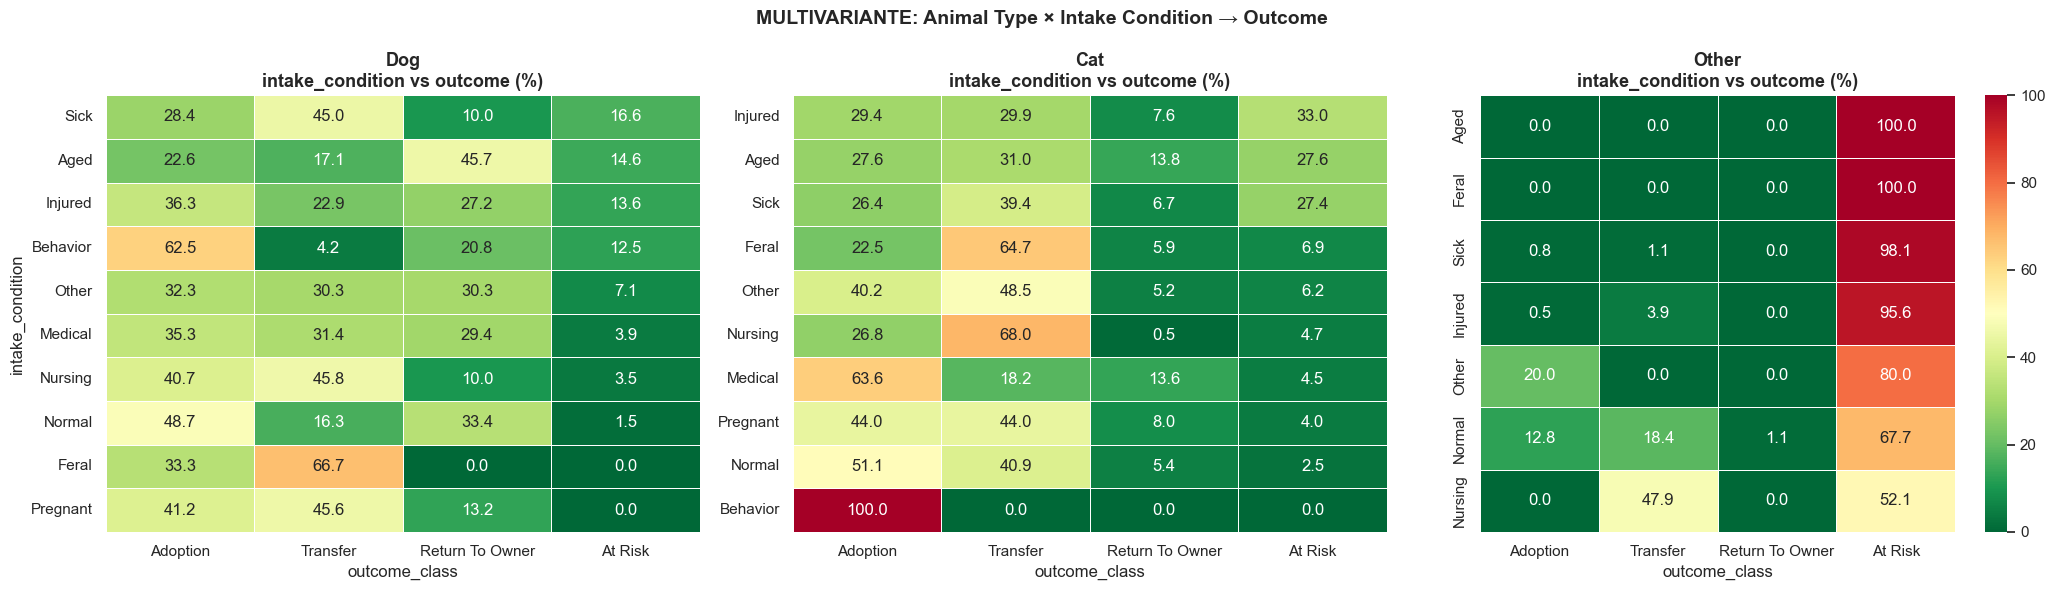

In [112]:
# Filtrar los tipos de animal más comunes
top_animals = df['animal_type_intake'].value_counts().head(3).index

fig, axes = plt.subplots(1, len(top_animals), figsize=(21, 6))

for i, animal in enumerate(top_animals):
    sub = df[df['animal_type_intake'] == animal]
    ct  = pd.crosstab(sub['intake_condition'], sub[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct = ct_pct.sort_values('At Risk', ascending=False)

    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=axes[i], linewidths=0.5,
                cbar=(i == len(top_animals)-1),
                vmin=0, vmax=100)
    axes[i].set_title(f'{animal}\nintake_condition vs outcome (%)')
    axes[i].set_ylabel('' if i > 0 else 'intake_condition')

plt.suptitle('MULTIVARIANTE: Animal Type × Intake Condition → Outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 20. Animal type × age_group → outcome
> ¿La edad tiene el mismo efecto en perros que en gatos?

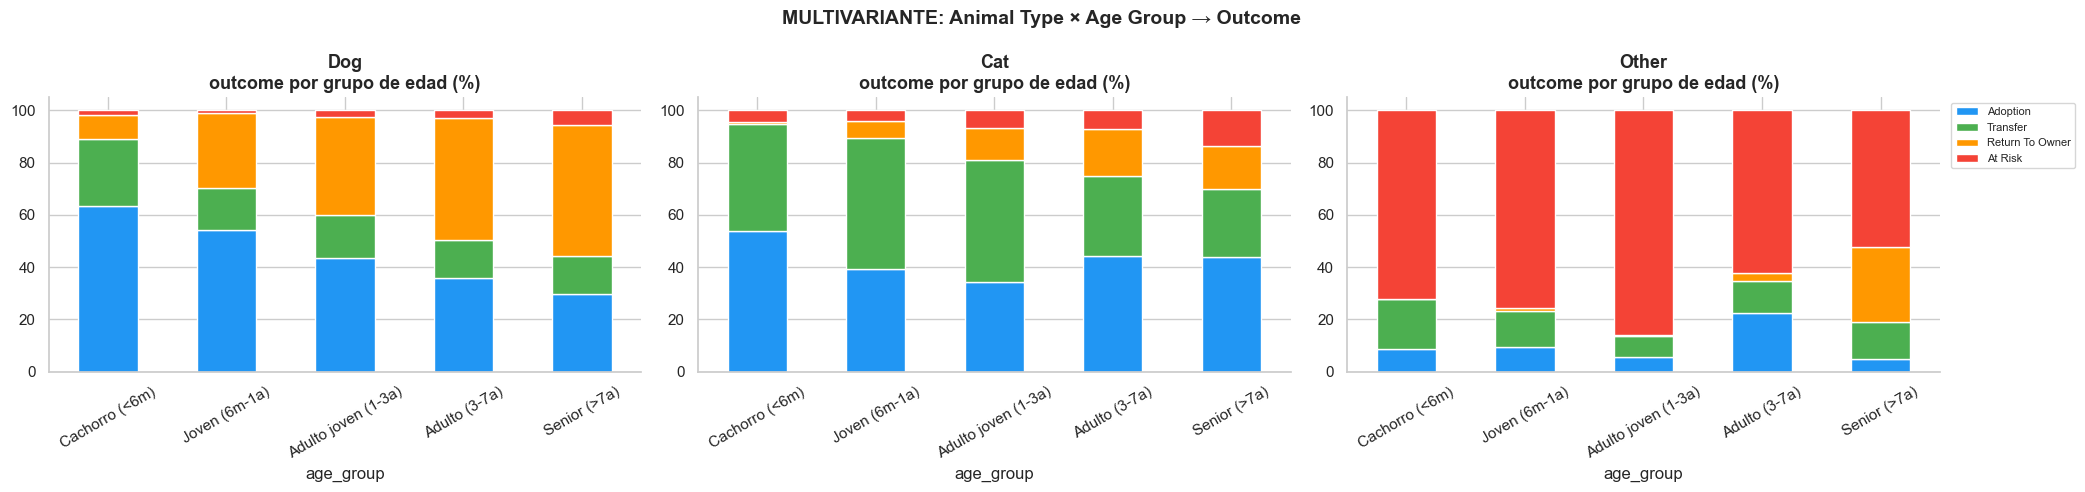

In [113]:
fig, axes = plt.subplots(1, len(top_animals), figsize=(21, 5))

for i, animal in enumerate(top_animals):
    sub = df[df['animal_type_intake'] == animal]
    ct  = pd.crosstab(sub['age_group'], sub[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], color=PALETTE, edgecolor='white')
    axes[i].set_title(f'{animal}\noutcome por grupo de edad (%)')
    axes[i].tick_params(axis='x', rotation=30)
    if i == len(top_animals)-1:
        axes[i].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
    else:
        axes[i].get_legend().remove()

plt.suptitle('MULTIVARIANTE: Animal Type × Age Group → Outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 21. Intake type × intake_condition → outcome
> ¿Cómo interactúan la causa y la condición de ingreso?

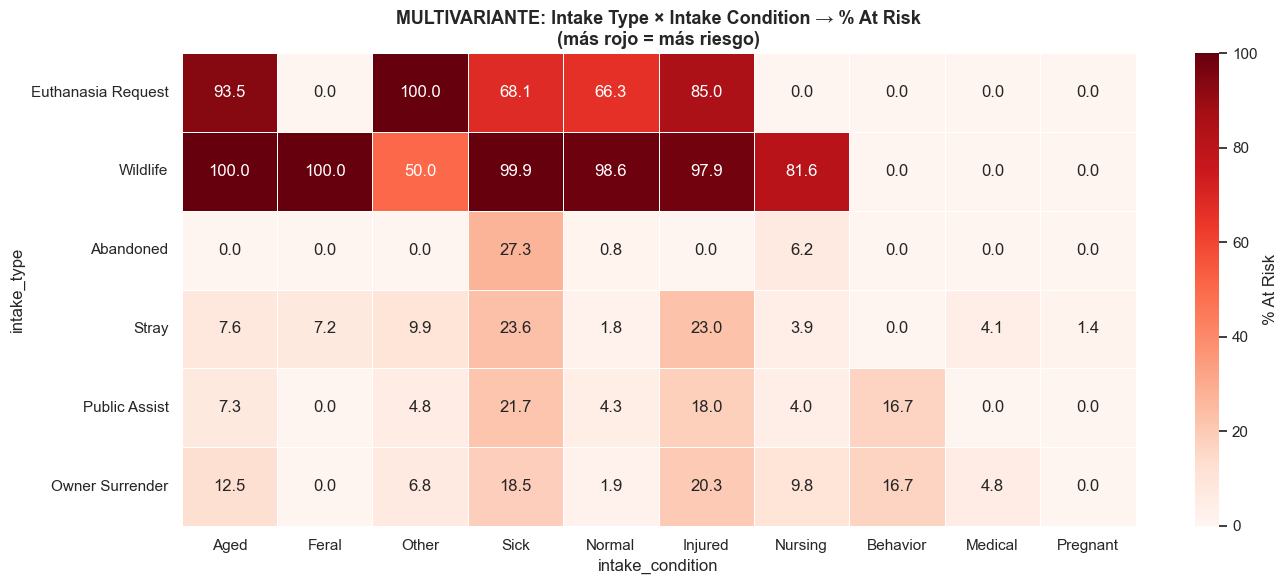

In [114]:
# % At Risk para cada combinación intake_type x intake_condition
pivot_at_risk = df.groupby(['intake_type','intake_condition']).apply(
    lambda x: (x[TARGET] == 'At Risk').mean() * 100
).unstack(fill_value=0)

# Ordenar filas y columnas por % At Risk
pivot_at_risk = pivot_at_risk.loc[
    pivot_at_risk.max(axis=1).sort_values(ascending=False).index,
    pivot_at_risk.max(axis=0).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_at_risk, annot=True, fmt='.1f', cmap='Reds',
            ax=ax, linewidths=0.5, cbar_kws={'label':'% At Risk'})
ax.set_title('MULTIVARIANTE: Intake Type × Intake Condition → % At Risk\n'
             '(más rojo = más riesgo)', fontweight='bold')
ax.set_ylabel('intake_type')
ax.set_xlabel('intake_condition')
plt.tight_layout()
plt.show()

---
## 22. Repro_status × animal_type → outcome
> ¿El estado reproductivo afecta igual a perros y gatos?

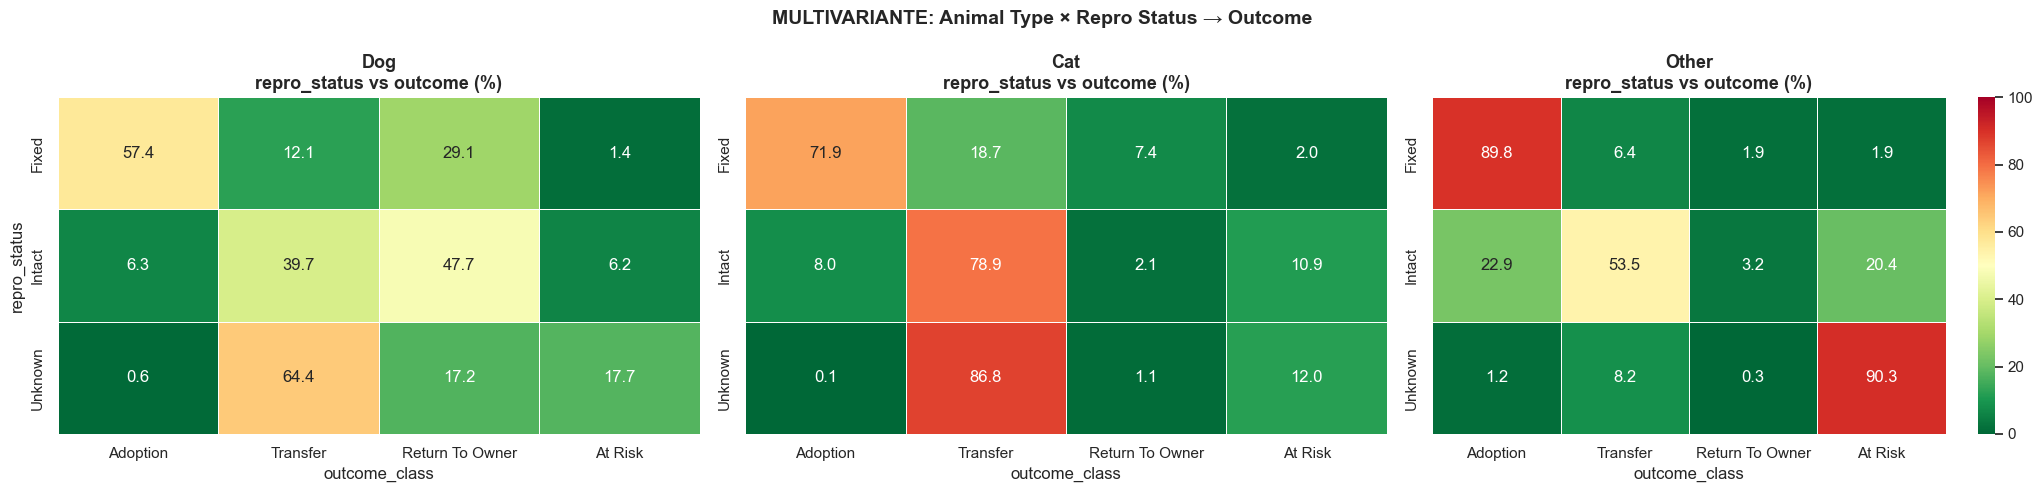

In [115]:
fig, axes = plt.subplots(1, len(top_animals), figsize=(21, 5))

for i, animal in enumerate(top_animals):
    sub = df[df['animal_type_intake'] == animal]
    ct  = pd.crosstab(sub['repro_status'], sub[TARGET]).reindex(columns=CLASS_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=axes[i], linewidths=0.5,
                cbar=(i == len(top_animals)-1),
                vmin=0, vmax=100)
    axes[i].set_title(f'{animal}\nrepro_status vs outcome (%)')
    axes[i].set_ylabel('' if i > 0 else 'repro_status')

plt.suptitle('MULTIVARIANTE: Animal Type × Repro Status → Outcome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 23. Matriz de correlaciones — variables numéricas

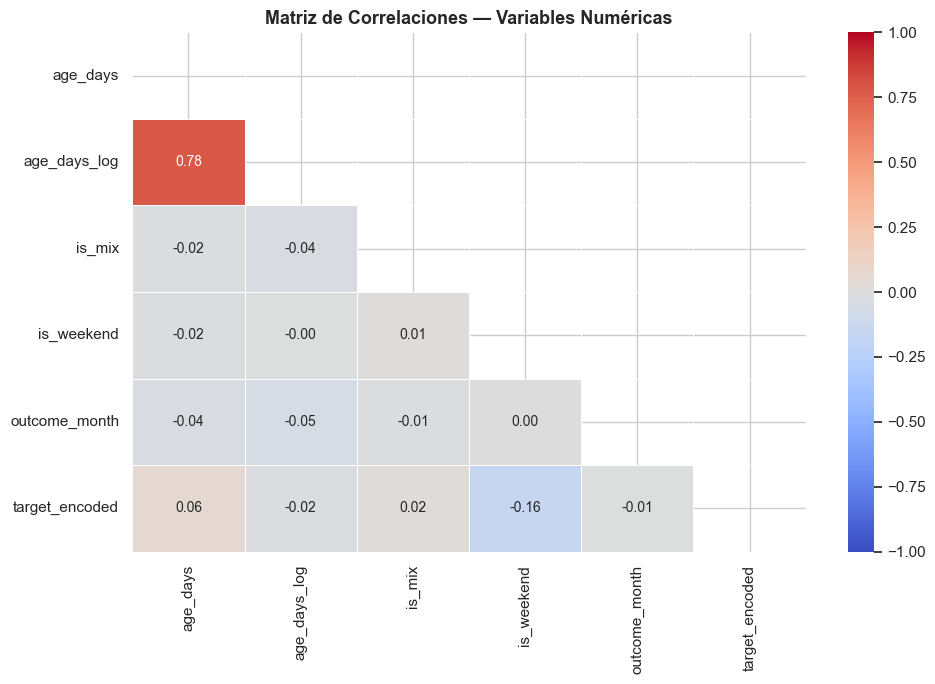

Correlación de cada variable con el target:


,corr con target
is_weekend,-0.160
age_days,0.064
is_mix,0.023
age_days_log,-0.019
outcome_month,-0.006


In [116]:
# Encoding del target para correlación
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df[TARGET])

NUM_CORR = ['age_days', 'age_days_log', 'is_mix', 'is_weekend',
            'outcome_month', 'target_encoded']
NUM_CORR = [c for c in NUM_CORR if c in df.columns]

corr = df[NUM_CORR].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size':10})
ax.set_title('Matriz de Correlaciones — Variables Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación con el target
print('Correlación de cada variable con el target:')
corr_target = corr['target_encoded'].drop('target_encoded').sort_values(key=abs, ascending=False)
display(corr_target.to_frame('corr con target')
          .style.bar(color=['#d65f5f','#5fba7d'], align='zero').format('{:.3f}'))

---
## 24. Pairplot — variables numéricas coloreado por clase

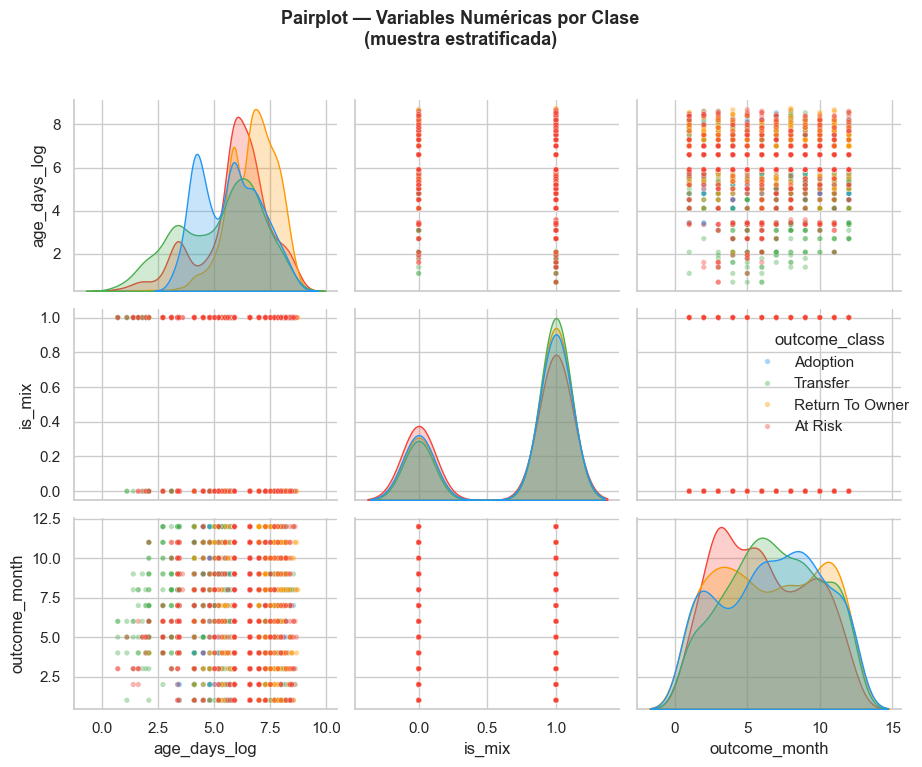

In [117]:
# Muestra estratificada para no saturar el plot
sample_sizes = {cls: min(800, (df[TARGET]==cls).sum()) for cls in CLASS_ORDER}
df_sample = pd.concat([
    df[df[TARGET]==cls].sample(n=sample_sizes[cls], random_state=42)
    for cls in CLASS_ORDER
])

PAIRPLOT_COLS = ['age_days_log', 'is_mix', 'outcome_month', TARGET]
PAIRPLOT_COLS = [c for c in PAIRPLOT_COLS if c in df_sample.columns]

g = sns.pairplot(
    df_sample[PAIRPLOT_COLS],
    hue=TARGET,
    hue_order=CLASS_ORDER,
    palette=CLASS_COLORS,
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Variables Numéricas por Clase\n(muestra estratificada)',
               y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 25. PCA — Separabilidad de las 4 clases
> Reduce todas las features a 2 dimensiones para ver si las clases son visualmente separables.

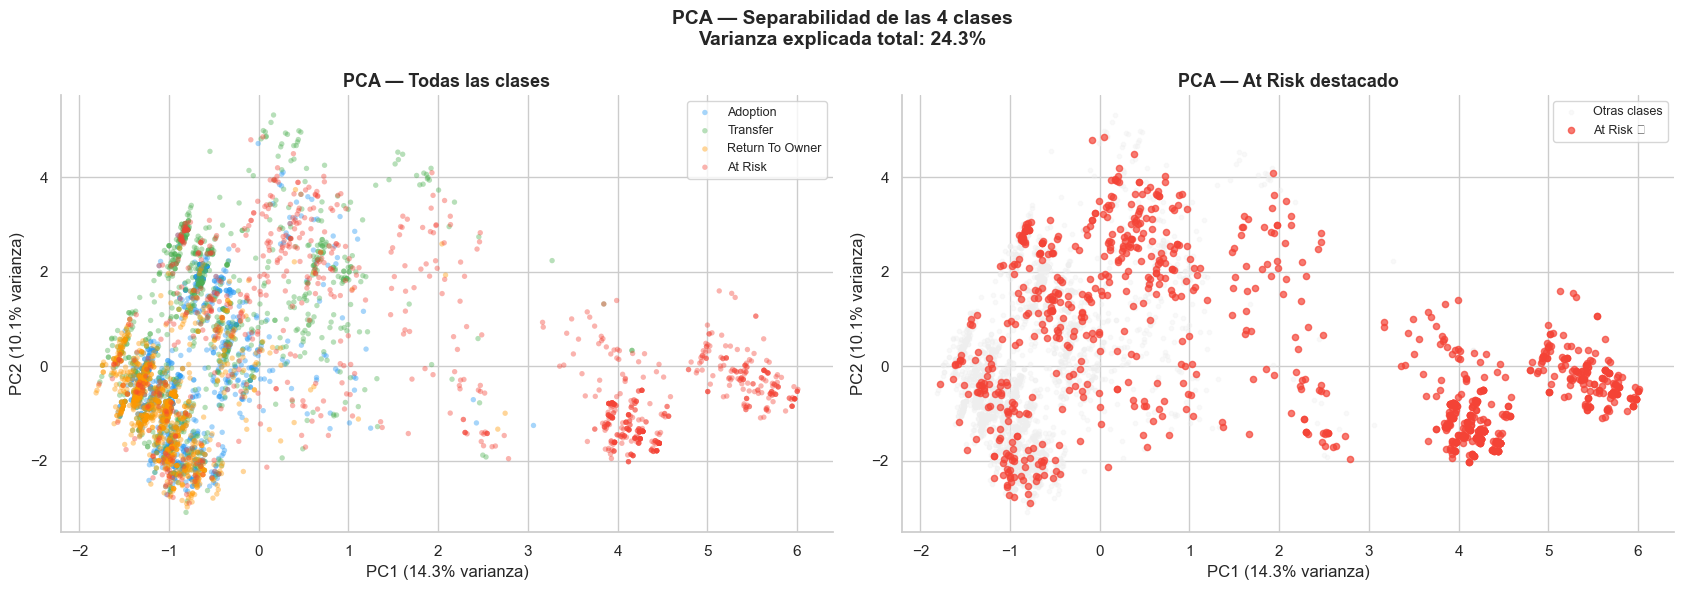

Varianza explicada — PC1: 14.3%  |  PC2: 10.1%


In [118]:
# Preparar features para PCA (encoding básico)
PCA_FEATURES = ['age_days_log', 'is_mix', 'is_weekend', 'outcome_month']

# Añadir dummies de las categóricas más importantes
for col in ['animal_type_intake', 'intake_type', 'intake_condition', 'repro_status', 'season']:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True, dtype=int)
        df = pd.concat([df, dummies], axis=1)
        PCA_FEATURES += dummies.columns.tolist()

PCA_FEATURES = [c for c in PCA_FEATURES if c in df.columns]

# Muestra estratificada
df_pca = pd.concat([
    df[df[TARGET]==cls].sample(n=min(1000,(df[TARGET]==cls).sum()), random_state=42)
    for cls in CLASS_ORDER
])

X_pca = df_pca[PCA_FEATURES].fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=['PC1','PC2'])
pca_df[TARGET] = df_pca[TARGET].values

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Scatter todas las clases
for cls in CLASS_ORDER:
    sub = pca_df[pca_df[TARGET] == cls]
    axes[0].scatter(sub['PC1'], sub['PC2'],
                    c=CLASS_COLORS[cls], label=cls,
                    alpha=0.4, s=15, edgecolors='none')
axes[0].set_title('PCA — Todas las clases')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[0].legend(fontsize=9)

# At Risk destacado
rest = pca_df[pca_df[TARGET] != 'At Risk']
atrisk = pca_df[pca_df[TARGET] == 'At Risk']
axes[1].scatter(rest['PC1'], rest['PC2'], c='#EEEEEE', alpha=0.3, s=10, label='Otras clases')
axes[1].scatter(atrisk['PC1'], atrisk['PC2'], c='#F44336', alpha=0.7, s=20, label='At Risk 🔴')
axes[1].set_title('PCA — At Risk destacado')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[1].legend(fontsize=9)

plt.suptitle(f'PCA — Separabilidad de las 4 clases\n'
             f'Varianza explicada total: {sum(pca.explained_variance_ratio_)*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Varianza explicada — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  |  '
      f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

---
# CIERRE
## 26. Conclusiones para el modelado

In [119]:
vc_f  = df[TARGET].value_counts().reindex(CLASS_ORDER)
pct_f = (vc_f / vc_f.sum() * 100).round(2)

print('=' * 65)
print('        📋  CONCLUSIONES — FASE 1 COMPLETA')
print('=' * 65)
print(f'''
📐 Dataset final: {df.shape[0]:,} filas · {df.shape[1]} columnas
✅ Nulos: 0  |  Duplicados: {df.duplicated().sum()}

── Distribución del target ──────────────────────────────────────
  Adoption        {vc_f["Adoption"]:>7,}  ({pct_f["Adoption"]:.1f}%)
  Transfer        {vc_f["Transfer"]:>7,}  ({pct_f["Transfer"]:.1f}%)
  Return To Owner {vc_f["Return To Owner"]:>7,}  ({pct_f["Return To Owner"]:.1f}%)
  At Risk 🔴      {vc_f["At Risk"]:>7,}  ({pct_f["At Risk"]:.1f}%)

── Hallazgos univariante ────────────────────────────────────────
  · La mayoría son perros y gatos
  · intake_condition tiene mucha variabilidad (Normal, Injured, Sick...)
  · age_days tiene distribución muy sesgada → usar age_days_log en el modelo

── Hallazgos bivariante ─────────────────────────────────────────
  · intake_condition es la variable más predictiva para At Risk
  · Animals Intact tienen mayor % At Risk que Fixed
  · Animales mayores (>10a) tienen el mayor % At Risk
  · Owner Surrender tiene alto % At Risk vs Stray

── Hallazgos multivariante ──────────────────────────────────────
  · El efecto de intake_condition sobre At Risk varía por tipo de animal
  · La edad afecta de forma diferente a perros vs gatos
  · La combinación intake_type × intake_condition es muy predictiva
  · El PCA muestra separación parcial → hay señal pero no perfecta
    (parte de la variabilidad es no predecible con estos datos)

── Features recomendadas para el modelo ─────────────────────────
  ✅ intake_condition   (Cramér's V más alto)
  ✅ intake_type
  ✅ animal_type_intake
  ✅ age_days_log       (versión log de la edad)
  ✅ repro_status
  ✅ sex
  ✅ is_mix
  ✅ season
  ✅ breed_intake       (target encoding por alta cardinalidad)
  ✅ primary_color      (target encoding por alta cardinalidad)

── Estrategia para At Risk (solo ~4%) ───────────────────────────
  → class_weight="balanced" en todos los modelos
  → SMOTE como alternativa
  → Métrica principal: Recall en At Risk (≥ 0.55)
  → Validación: StratifiedKFold k=5
  → Split: 60% train / 20% val / 20% test
''')

        📋  CONCLUSIONES — FASE 1 COMPLETA

📐 Dataset final: 160,216 filas · 42 columnas
✅ Nulos: 0  |  Duplicados: 38498

── Distribución del target ──────────────────────────────────────
  Adoption         73,712  (46.0%)
  Transfer         40,040  (25.0%)
  Return To Owner  36,005  (22.5%)
  At Risk 🔴       10,459  (6.5%)

── Hallazgos univariante ────────────────────────────────────────
  · La mayoría son perros y gatos
  · intake_condition tiene mucha variabilidad (Normal, Injured, Sick...)
  · age_days tiene distribución muy sesgada → usar age_days_log en el modelo

── Hallazgos bivariante ─────────────────────────────────────────
  · intake_condition es la variable más predictiva para At Risk
  · Animals Intact tienen mayor % At Risk que Fixed
  · Animales mayores (>10a) tienen el mayor % At Risk
  · Owner Surrender tiene alto % At Risk vs Stray

── Hallazgos multivariante ──────────────────────────────────────
  · El efecto de intake_condition sobre At Risk varía por tipo de ani

---
## 27. Exportar `animal_classification.csv`

In [120]:
FINAL_FEATURES = [
    'animal_type_intake', 'breed_intake', 'color_intake', 'primary_color',
    'sex_upon_intake', 'intake_type', 'intake_condition',
    'age_days', 'age_days_log', 'age_group',
    'is_mix', 'sex', 'repro_status', 'sex_repro',
    'season', 'is_weekend', 'outcome_month',
    TARGET
]

final_cols = [c for c in FINAL_FEATURES if c in df.columns]
df_out = df[final_cols].copy()

OUTPUT = '../data/processed/animal_classification.csv'
df_out.to_csv(OUTPUT, index=False)

print('=' * 55)
print('  ✅ animal_classification.csv guardado')
print('=' * 55)
print(f'  Filas    : {df_out.shape[0]:,}')
print(f'  Columnas : {df_out.shape[1]}')
print(f'  Nulos    : {df_out.isnull().sum().sum()}')
print()
print('  Columnas del archivo:')
for c in df_out.columns:
    dtype = str(df_out[c].dtype)
    print(f'    {c:<25} ({dtype})')

  ✅ animal_classification.csv guardado
  Filas    : 160,216
  Columnas : 18
  Nulos    : 0

  Columnas del archivo:
    animal_type_intake        (str)
    breed_intake              (str)
    color_intake              (str)
    primary_color             (object)
    sex_upon_intake           (str)
    intake_type               (str)
    intake_condition          (str)
    age_days                  (float64)
    age_days_log              (float64)
    age_group                 (category)
    is_mix                    (int64)
    sex                       (str)
    repro_status              (str)
    sex_repro                 (str)
    season                    (str)
    is_weekend                (int64)
    outcome_month             (int64)
    outcome_class             (str)
